## RGB conversion of a batch of images

- This notebook takes as input the `water_detection_params.yaml`, where all the parameters that have been manually selected from `rgb_conversion_interactive.ipynb` have been written.
- The goal is to compute the baseline and automatically generate the final matrices with water mask and vegetation score for all the images in the considered batch, and then save these matrices in a specified folder.

## 1. Import Required Libraries and Modules
This cell imports all necessary Python libraries and project modules for image processing, configuration loading, and visualization. It also sets up the Python path and loads color maps for later use.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import yaml
import glob
from skimage.exposure import match_histograms
from sklearn.preprocessing import MinMaxScaler
import json

# Add the parent directory to Python path
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import RGB processing module
from beaversim.utils.rgb_to_matrix import (
    load_rgb_image,
    calculate_ndvi,
    calculate_vari,
    calculate_excess_green,
    calculate_cwi,
    detect_water_simple,        
    apply_shadow_correction,
    postprocess_water_mask,
)

# Import colormap for visualization
try:
    from beaversim.ral.backend.modules.module_colors import ColorMaps
    colors = ColorMaps()
    print("✓ Modules loaded successfully")
except ImportError:
    print("⚠ Warning: ColorMaps not available, using default matplotlib colormaps")
    colors = None
    
# Global variables
MAX_COLS = 3

✓ Modules loaded successfully


## 2. Load Configuration Parameters
This cell loads the processing parameters from a YAML configuration file, including paths, baseline method, shadow correction, and per-image settings. It prepares the configuration for all subsequent steps.

In [2]:
# ============================================================================
# LOAD PARAMETERS FROM YAML CONFIG
# ============================================================================
CONFIG_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'config/water_detection_params_C5.yaml')

with open(CONFIG_PATH, 'r') as f:
    params = yaml.safe_load(f)

source_path = params['source_path'].replace('beaversim/utils/', './')
output_path = params['output_path'].replace('beaversim/utils/', './')

# ── General (shared) parameters ──────────────────────────────────────────────
general = params['pictures']['general']

BASELINE_METHOD      = str(general.get('baseline', 'median')).lower()   # 'mean' or 'median'
SHADOW_CORRECTION    = general.get('shadow_correction', general.get('shadow_correction', True))
VEGETATION_INDEX     = general.get('vegetation_index', 'NDVI')
WATER_INDEX          = general.get('water_index', 'NDVI')
WATER_THRESHOLD      = general.get('threshold', None)
OPENING_SIZES        = general.get('opening_sizes', [])
MEDIAN_SIZES         = general.get('median_sizes', [])
CLOSING_SIZES        = general.get('closing_sizes', [])
USE_SAM2             = general.get('use_sam2', False)
TARGET_SIZE          = None if str(general.get('target_size', 'None')) == 'None' else general['target_size']

# ── Per-image config (skip the 'general' key) ────────────────────────────────
IMAGE_CONFIGS = {}
for pic_key, pic_val in params['pictures'].items():
    if pic_key == 'general':
        continue
    IMAGE_CONFIGS[pic_key] = {
        'name':       f"{pic_key} ({pic_val['image']})",
        'image_path': os.path.join(source_path, pic_val['image']),
        'output_dir': os.path.join(output_path, pic_key),
        # Allow per-image overrides, otherwise fall back to general values
        'target_size':        None if str(pic_val.get('target_size', TARGET_SIZE or 'None')) == 'None'
                              else pic_val.get('target_size', TARGET_SIZE),
        'shadow_correction':  pic_val.get('shadow_correction', SHADOW_CORRECTION),
        'use_sam2':           pic_val.get('use_sam2', USE_SAM2),
        'water_index':        pic_val.get('water_index', WATER_INDEX),
        'vegetation_index':   pic_val.get('vegetation_index', VEGETATION_INDEX),
        'threshold':          pic_val.get('threshold', WATER_THRESHOLD),
        'opening_sizes':      pic_val.get('opening_sizes', OPENING_SIZES),
        'median_sizes':       pic_val.get('median_sizes', MEDIAN_SIZES),
        'closing_sizes':      pic_val.get('closing_sizes', CLOSING_SIZES),
    }

print(f"✓ Configuration loaded from: {CONFIG_PATH}")
print(f"  Source folder   : {source_path}")
print(f"  Baseline method : {BASELINE_METHOD.upper()}")
print(f"  Shadow correction: {SHADOW_CORRECTION}")
print(f"  Water index     : {WATER_INDEX}  (threshold: {WATER_THRESHOLD})")
print(f"  Vegetation index: {VEGETATION_INDEX}")
print(f"  Images found    : {len(IMAGE_CONFIGS)}")
for k, v in IMAGE_CONFIGS.items():
    print(f"    {k}: {v['name']}")


✓ Configuration loaded from: /home/fedeoli/Documents/Work/Projects/beavers/beaverbot/beaversim/utils/config/water_detection_params_C5.yaml
  Source folder   : ./example_datasets/RUMNEY_MARSH/C5
  Baseline method : MEAN
  Shadow correction: True
  Water index     : CWI  (threshold: -0.43)
  Vegetation index: VARI
  Images found    : 3
    C5_01: C5_01 (C5_06152018.PNG)
    C5_02: C5_02 (C5_07152018.PNG)
    C5_03: C5_03 (C5_08212018.PNG)


## 3. Compute Baseline Image
This cell loads all images from the source folder, computes the mean and median RGB baselines, applies shadow correction, and visualizes the results. The baseline is used as a stable reference for water detection and normalization.

Found 3 image(s) in: ./example_datasets/RUMNEY_MARSH/C5
  Image loaded: (813, 1285, 3) (H x W x C)
  Image loaded: (813, 1285, 3) (H x W x C)
  Image loaded: (813, 1285, 3) (H x W x C)
  Image loaded: (813, 1285, 3) (H x W x C)
  Shadow correction applied
  Shadow correction applied

✓ Baseline method: MEDIAN


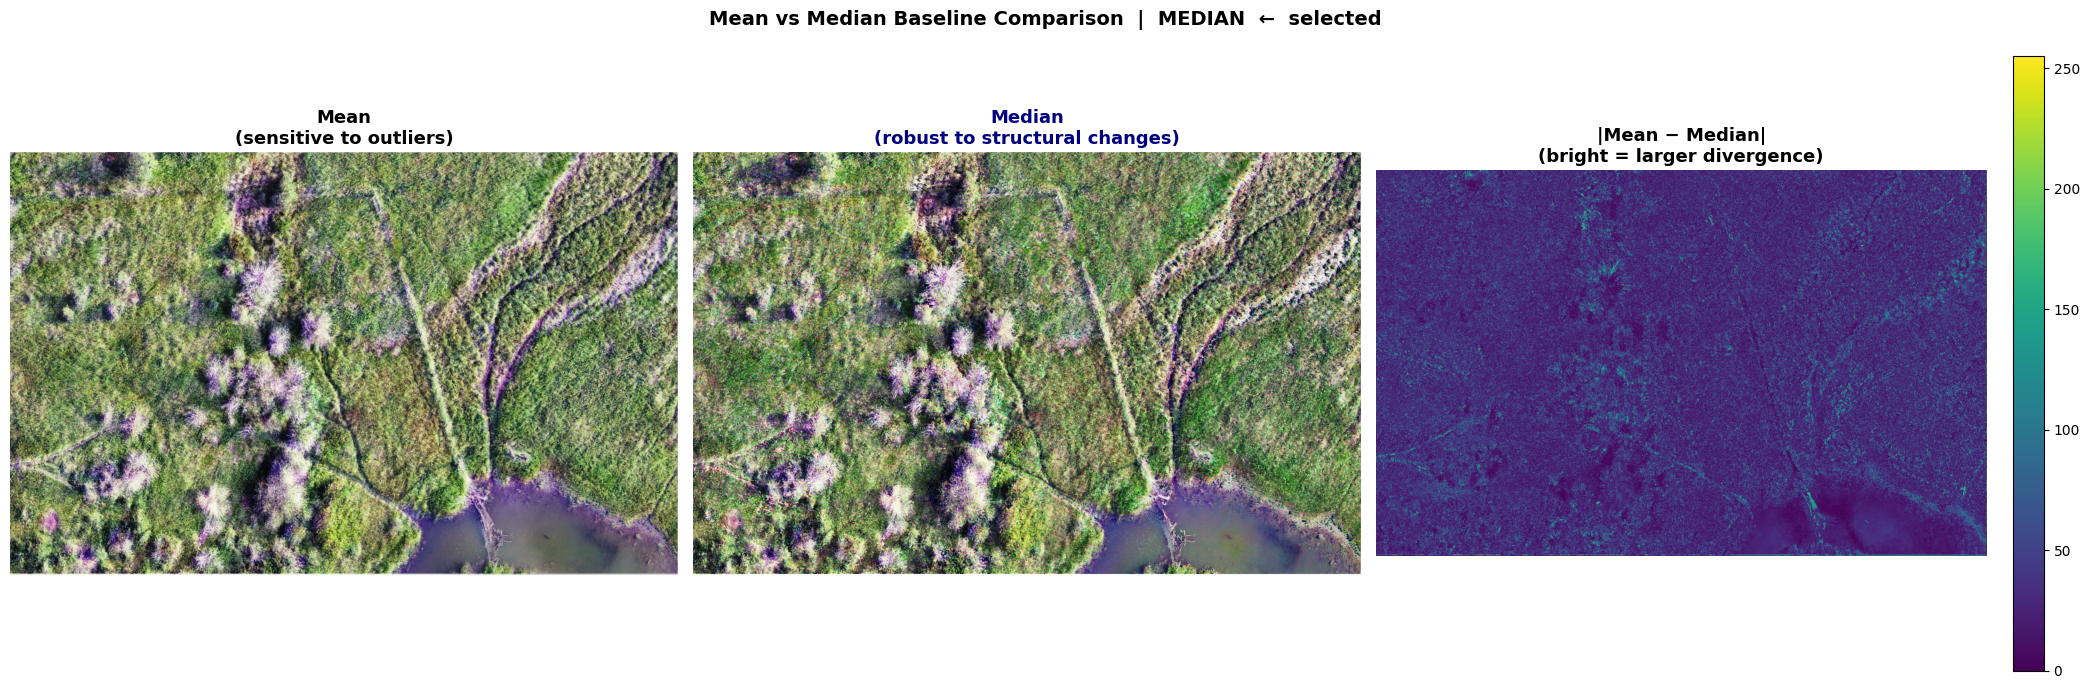

In [3]:
# ============================================================================
# AGGREGATION METHOD
# 'mean'   – pixel-wise average (fast, smooth, sensitive to outliers)
# 'median' – pixel-wise temporal median (robust to structural changes)
# ============================================================================
BASELINE_METHOD = 'median'

# ============================================================================
# Load all images from GENERAL_FOLDER
# ============================================================================
SUPPORTED_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
image_paths = sorted([
    p for p in glob.glob(os.path.join(source_path, '*'))
    if p.lower().endswith(SUPPORTED_EXTS)
])

if not image_paths:
    raise FileNotFoundError(f"No images found in source_path: {source_path}")

print(f"Found {len(image_paths)} image(s) in: {source_path}")

# Load all images, resize to the same size as the first one
ref_rgb, _ = load_rgb_image(image_paths[0], target_size=TARGET_SIZE)
H, W = ref_rgb.shape[:2]

# Stack all images into a 4D array (N, H, W, 3)
rgb_stack = np.zeros((len(image_paths), H, W, 3), dtype=np.float32)
for i, path in enumerate(image_paths):
    img, _ = load_rgb_image(path, target_size=(W, H))
    rgb_stack[i] = img.astype(np.float32)

# Compute both so we can compare them
rgb_mean   = np.clip(rgb_stack.mean(axis=0), 0, 255).astype(np.uint8)
rgb_median = np.clip(np.median(rgb_stack, axis=0), 0, 255).astype(np.uint8)

# Apply shadow correction to the baseline image
if SHADOW_CORRECTION:
    rgb_mean_corrected = apply_shadow_correction(rgb_mean, method='clahe')
    rgb_median_corrected = apply_shadow_correction(rgb_median, method='clahe')
else:
    rgb_mean_corrected = rgb_mean.copy()
    rgb_median_corrected = rgb_median.copy()

# Select baseline according to chosen method
if BASELINE_METHOD == 'median':
    rgb_baseline = rgb_median_corrected
else:
    rgb_baseline = rgb_mean_corrected

print(f"\n✓ Baseline method: {BASELINE_METHOD.upper()}")

# ============================================================================
# Compare Mean vs Median side-by-side
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

axes[0].imshow(rgb_mean_corrected)
axes[0].set_title('Mean\n(sensitive to outliers)', fontsize=13, fontweight='bold',
                  color='navy' if BASELINE_METHOD == 'mean' else 'black')
axes[0].axis('off')

axes[1].imshow(rgb_median_corrected)
axes[1].set_title('Median\n(robust to structural changes)', fontsize=13, fontweight='bold',
                  color='navy' if BASELINE_METHOD == 'median' else 'black')
axes[1].axis('off')

# Absolute per-pixel difference (averaged over channels, normalised for visibility)
diff = np.abs(rgb_mean_corrected.astype(np.int16) - rgb_median_corrected.astype(np.int16)).mean(axis=2)
diff_norm = (diff / diff.max() * 255).astype(np.uint8) if diff.max() > 0 else diff.astype(np.uint8)
im = axes[2].imshow(diff_norm, cmap='viridis')
axes[2].set_title('|Mean − Median|\n(bright = larger divergence)', fontsize=13, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

selected_label = 'MEDIAN  ←  selected' if BASELINE_METHOD == 'median' else 'MEAN  ←  selected'
plt.suptitle(f'Mean vs Median Baseline Comparison  |  {selected_label}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Compute Vegetation Indices and Water Mask on Baseline
This cell calculates vegetation indices (NDVI, VARI, ExG, CWI) on the shadow-corrected baseline image, selects the water index, determines the threshold, detects water, and applies morphological post-processing. It visualizes the water detection results.

  NDVI rescaled range: [-1.000, 1.000]
  NDVI rescaled mean: 0.086
  VARI rescaled range: [-1.000, 1.000]
  VARI rescaled mean: 0.355
  ExG rescaled range: [-1.000, 1.000]
  ExG rescaled mean: 0.012
  CWI rescaled range: [-1.000, 1.000]
  CWI rescaled mean: -0.407
✓ Baseline indices computed (NDVI, VARI, ExG, CWI)
  Using MANUAL threshold : -0.430  (CWI)
  Using CWI > -0.430 (CWI: high values = water)
  Water pixels detected: 532,752 (51.00%)
  Phase 1: Applying 1 opening(s) (erosion + dilation)...
    Opening 1 (kernel=80): Removed 470,689 noise pixels
  Phase 3: Applying 1 morphological closing(s)...
  Summary: 532,752 → 58,658 pixels (-89.0%)

✓ Water mask ready  |  5.61% water  (58,658 px)


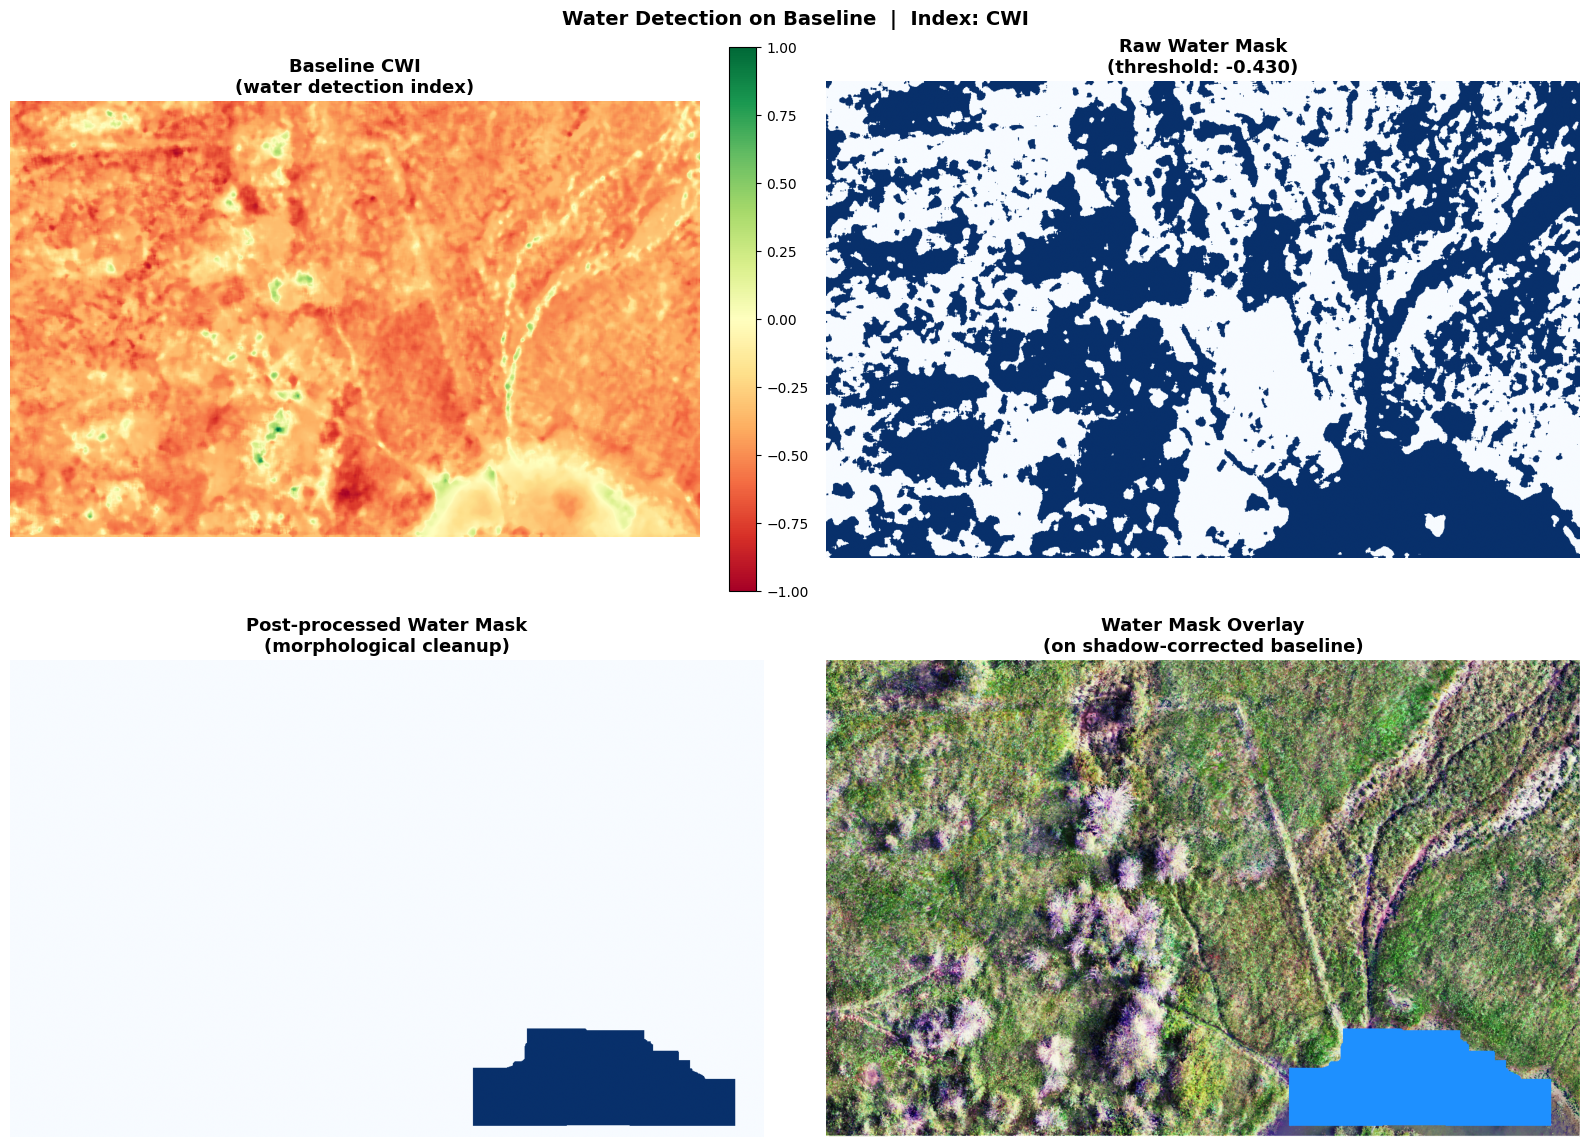

In [4]:
# ============================================================================
# STEP 1: Compute Vegetation Indices on Baseline & Water Detection
# Indices are computed on rgb_baseline, (after shadow correction if applicable).
# The water index specified in the config (WATER_INDEX) is thresholded to
# produce a water mask, then cleaned up with morphological operations.
# ============================================================================

# ── Compute all indices on the baseline ──────────────────────────────────────
ndvi_baseline = calculate_ndvi(rgb_baseline, method='visible')
vari_baseline = calculate_vari(rgb_baseline)
exg_baseline  = calculate_excess_green(rgb_baseline)
cwi_baseline  = calculate_cwi(rgb_baseline)

index_map = {
    'NDVI': ndvi_baseline,
    'VARI': vari_baseline,
    'ExG':  exg_baseline,
    'CWI':  cwi_baseline,
}

print('✓ Baseline indices computed (NDVI, VARI, ExG, CWI)')

# ── Select water index ────────────────────────────────────────────────────────
if WATER_INDEX not in index_map:
    raise ValueError(f"Unknown WATER_INDEX: '{WATER_INDEX}'. Choose from {list(index_map)}")
water_veg_index = index_map[WATER_INDEX]

# ── Determine threshold ───────────────────────────────────────────────────────
index_threshold = float(WATER_THRESHOLD)
print(f"  Using MANUAL threshold : {index_threshold:.3f}  ({WATER_INDEX})")

# ── Raw water detection ───────────────────────────────────────────────────────
water_mask_raw = detect_water_simple(
    rgb_baseline,
    water_veg_index,
    index_name=WATER_INDEX,
    index_threshold=index_threshold,
)

# ── Morphological post-processing ────────────────────────────────────────────
water_mask = postprocess_water_mask(
    water_mask_raw,
    opening_sizes=OPENING_SIZES,
    median_sizes=MEDIAN_SIZES,
    closing_sizes=CLOSING_SIZES,
    apply_opening=len(OPENING_SIZES) > 0,
    apply_median=len(MEDIAN_SIZES) > 0,
    apply_closing=len(CLOSING_SIZES) > 0,
)

water_pct = 100 * water_mask.sum() / water_mask.size
print(f"\n✓ Water mask ready  |  {water_pct:.2f}% water  ({water_mask.sum():,} px)")

# ── Visualize (2×2) ──────────────────────────────────────────────────────────
cmap_idx = plt.cm.RdYlGn.copy()
cmap_idx.set_under('dodgerblue')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (0,0) Selected water index on baseline
im_idx = axes[0, 0].imshow(water_veg_index, cmap=cmap_idx, vmin=-1, vmax=1)
axes[0, 0].set_title(f'Baseline {WATER_INDEX}\n(water detection index)', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im_idx, ax=axes[0, 0], fraction=0.046, pad=0.04)

# (0,1) Raw water mask
axes[0, 1].imshow(water_mask_raw, cmap='Blues')
axes[0, 1].set_title(f'Raw Water Mask\n(threshold: {index_threshold:.3f})', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# (1,0) Post-processed mask
axes[1, 0].imshow(water_mask, cmap='Blues')
axes[1, 0].set_title('Post-processed Water Mask\n(morphological cleanup)', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

# (1,1) Overlay on baseline
rgb_overlay = rgb_baseline.copy()
rgb_overlay[water_mask] = [30, 144, 255]
axes[1, 1].imshow(rgb_overlay)
axes[1, 1].set_title('Water Mask Overlay\n(on shadow-corrected baseline)', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle(f'Water Detection on Baseline  |  Index: {WATER_INDEX}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Load, Shadow-Correct, and Mask All Images
This cell loads each image, applies shadow correction, resizes the water mask if needed, and paints water pixels blue. The processed images are stored for further analysis.

In [5]:
# ============================================================================
# STEP 2: Load All Images, Shadow-Correct & Apply Water Mask
# For each image in IMAGE_CONFIGS:
#   - Load the original image
#   - Apply shadow correction
#   - Resize water_mask to match image resolution if needed
#   - Paint water pixels dodger-blue → rgb_masked
# Results are stored in processed_images[key] for use in Step 3.
# ============================================================================

processed_images = {}   # key → dict with rgb_original, rgb, water_mask_resized, rgb_masked

for key, cfg in IMAGE_CONFIGS.items():
    rgb_original, _ = load_rgb_image(cfg['image_path'], target_size=cfg['target_size'])

    # Shadow correction
    if cfg['shadow_correction']:
        rgb = apply_shadow_correction(rgb_original, method='clahe')
    else:
        rgb = rgb_original.copy()

    # Resize water mask to match image resolution if needed
    img_h, img_w = rgb.shape[:2]
    mask_h, mask_w = water_mask.shape
    if (mask_h, mask_w) != (img_h, img_w):
        water_mask_resized = np.array(
            Image.fromarray(water_mask.astype(np.uint8)).resize((img_w, img_h), Image.NEAREST)
        ).astype(bool)
    else:
        water_mask_resized = water_mask

    # Paint water pixels dodger-blue
    rgb_masked = rgb.copy()
    rgb_masked[water_mask_resized] = [30, 144, 255]

    processed_images[key] = {
        'rgb_original':       rgb_original,
        'rgb':                rgb,
        'water_mask_resized': water_mask_resized,
        'rgb_masked':         rgb_masked,
    }    

print(f"\n✓ All {len(processed_images)} images loaded and processed")


  Image loaded: (813, 1285, 3) (H x W x C)
  Shadow correction applied
  Image loaded: (809, 1286, 3) (H x W x C)
  Shadow correction applied
  Image loaded: (813, 1287, 3) (H x W x C)
  Shadow correction applied

✓ All 3 images loaded and processed


## 6. Histogram Matching for Weather Normalization
This cell matches the histogram of each image (land pixels only) to the shadow-corrected baseline, correcting for lighting differences. The result is used to ensure vegetation indices reflect real changes, not illumination artifacts.

In [6]:
# ============================================================================
# STEP 3: Histogram Matching (Weather Normalisation)
# For each image, match its histogram to the shadow-corrected baseline using
# land-only pixels as the reference distribution.  The result (rgb_matched)
# corrects for variable lighting so that vegetation indices in Step 4 reflect
# genuine vegetation change rather than illumination artefacts.
# Adds 'rgb_matched' to each processed_images[key] entry.
# ============================================================================

base_h, base_w = rgb_baseline.shape[:2]

for key, entry in processed_images.items():
    rgb       = entry['rgb']
    land      = ~entry['water_mask_resized']

    sel_h, sel_w = rgb.shape[:2]

    # Resize baseline to match image resolution if needed
    if (base_h, base_w) != (sel_h, sel_w):
        ref_for_match = np.array(
            Image.fromarray(rgb_baseline).resize((sel_w, sel_h), Image.BILINEAR)
        ).astype(np.uint8)
    else:
        ref_for_match = rgb_baseline

    # Per-channel matching using land pixels only as reference distribution
    rgb_matched = np.empty_like(rgb)
    for ch in range(3):
        src_flat = rgb[:, :, ch].astype(np.float32).ravel()
        ref_land = ref_for_match[:, :, ch].astype(np.float32)[land]   # 1-D land reference
        matched_flat = match_histograms(src_flat, ref_land)
        rgb_matched[:, :, ch] = np.clip(matched_flat.reshape(rgb.shape[:2]), 0, 255).astype(np.uint8)

    entry['ref_for_match'] = ref_for_match
    entry['rgb_matched']   = rgb_matched
    print(f"  ✓ {key:8s}  histogram matched")

print(f"\n✓ All {len(processed_images)} images histogram-matched")


  ✓ C5_01     histogram matched
  ✓ C5_02     histogram matched
  ✓ C5_03     histogram matched

✓ All 3 images histogram-matched


## 7. Compute Vegetation Quality Score and Final Matrix
This cell computes the selected vegetation index for each image, compares it to the baseline, and calculates a quality score. Water pixels are set to -1. The results are visualized and stored for further analysis.

  VARI rescaled range: [-1.000, 1.000]
  VARI rescaled mean: 0.177
  ✓ C5_01     VARI: land range [0.000, 1.000]  mean 0.300
  VARI rescaled range: [-1.000, 1.000]
  VARI rescaled mean: 0.150
  ✓ C5_02     VARI: land range [0.000, 1.000]  mean 0.303
  VARI rescaled range: [-1.000, 1.000]
  VARI rescaled mean: -0.080
  ✓ C5_03     VARI: land range [0.000, 1.000]  mean 0.218
Cropping all images and matrices to smallest size: (809, 1285)


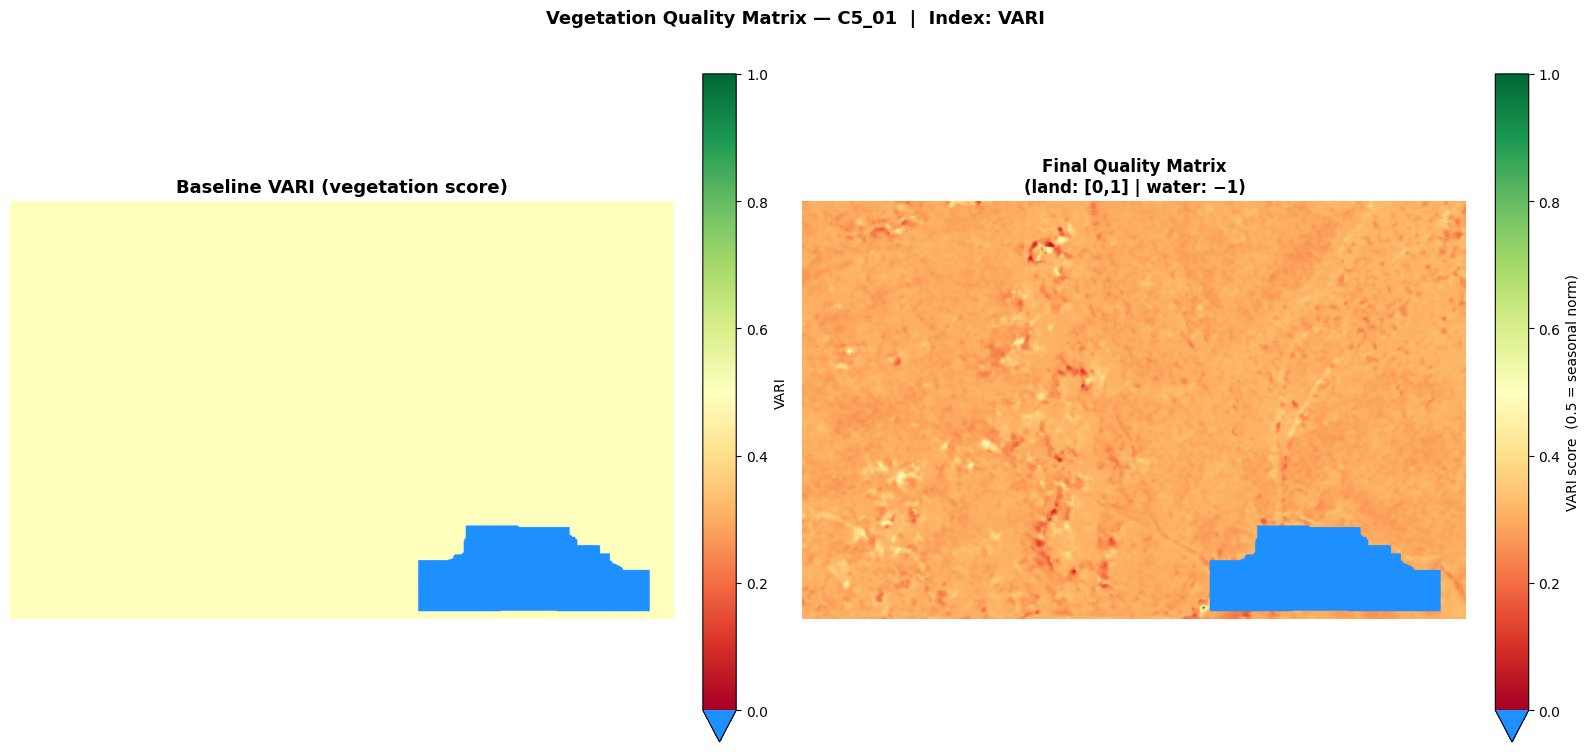

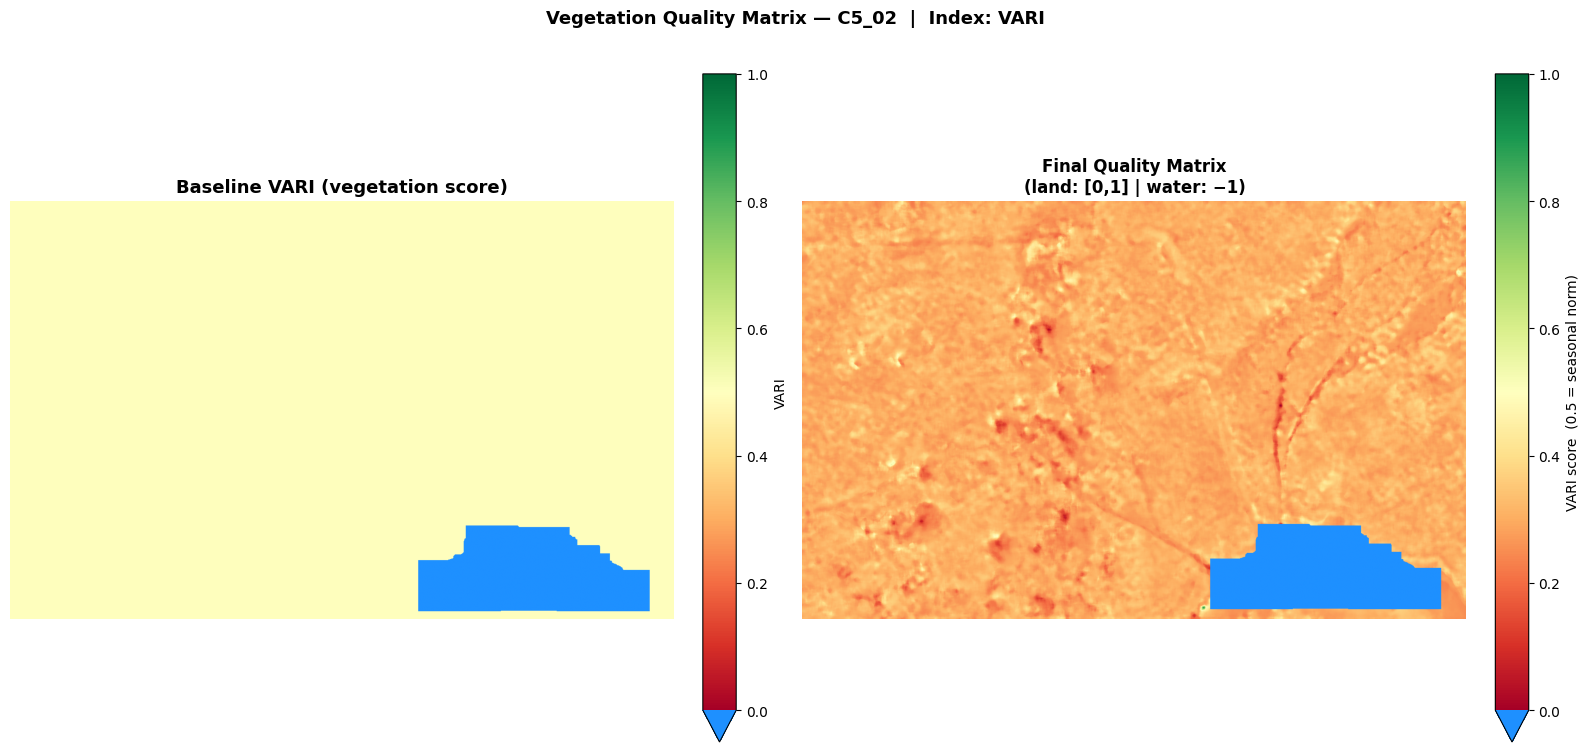

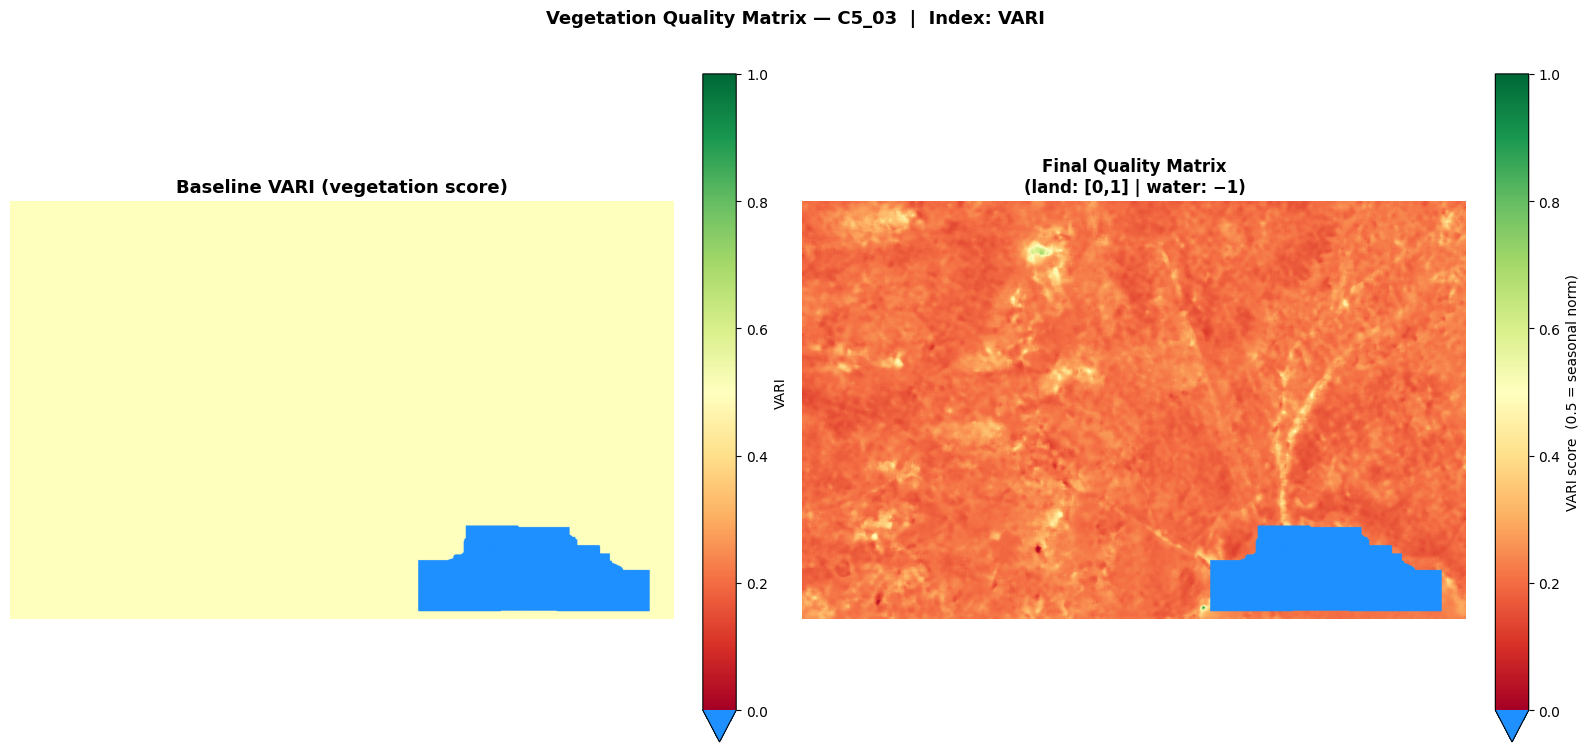

In [11]:
# ============================================================================
# STEP 4: Vegetation Quality Score & Final Matrix
# For each image:
#   - Compute VEGETATION_INDEX on rgb_matched
#   - Score = (1 + index_selected) / (2 * (1 + index_baseline + EPS))
#   - Water pixels → -1
#   - Store final_matrix and save outputs to disk
# ============================================================================

EPS = 1.0   # stability epsilon for near-zero baseline values
FINAL_VALUE = 'vegetation_score'  # 'vegetation_score' or 'index_selected'

# Baseline index (computed in Step 1 on rgb_baseline_corrected)
index_map = {
    'NDVI': ndvi_baseline,
    'VARI': vari_baseline,
    'ExG':  exg_baseline,
    'CWI':  cwi_baseline,
}
if VEGETATION_INDEX not in index_map:
    raise ValueError(f"Unknown VEGETATION_INDEX '{VEGETATION_INDEX}'. Choose from {list(index_map)}")
index_baseline_arr = index_map[VEGETATION_INDEX]

index_fn_map = {
    'NDVI': lambda img: calculate_ndvi(img, method='visible'),
    'VARI': calculate_vari,
    'ExG':  calculate_excess_green,
    'CWI':  calculate_cwi,
}
compute_index = index_fn_map[VEGETATION_INDEX]

for key, entry in processed_images.items():
    rgb_matched = entry['rgb_matched']
    wm          = entry['water_mask_resized']
    land_mask        = ~wm

    # --- Compute vegetation index on matched image ---
    index_selected = compute_index(rgb_matched).astype(np.float32)

    # --- Resize baseline index to match image resolution if needed ---
    if index_baseline_arr.shape != index_selected.shape:
        h, w = index_selected.shape
        ib_min, ib_max = index_baseline_arr.min(), index_baseline_arr.max()
        ib_range = ib_max - ib_min if ib_max > ib_min else 1.0
        ib_u8 = ((index_baseline_arr - ib_min) / ib_range * 255).clip(0, 255).astype(np.uint8)
        ib_resized = np.array(
            Image.fromarray(ib_u8).resize((w, h), Image.BILINEAR)
        ).astype(np.float32) / 255.0 * ib_range + ib_min
    else:
        ib_resized = index_baseline_arr.astype(np.float32)

    # --- Score: (1 + index_selected) / (2 * (1 + index_baseline + eps)) → [0, 1] ---
    vegetation_score = (1.0 + index_selected + EPS) / (2.0 * (1.0 + ib_resized + EPS))    

    # --- Baseline image: INDEX on land, -1 on water ---
    baseline_score = (1.0 + ib_resized + EPS) / (2.0 * (1.0 + ib_resized + EPS))    
    baseline_matrix = baseline_score.copy()
    baseline_matrix[wm] = -1.0

    # --- Final matrix: land = score, water = -1 ---
    if FINAL_VALUE == 'index_selected':
        valid_mask = np.isfinite(index_selected) & land_mask
        scaler = MinMaxScaler(feature_range=(0, 1))
        ind_valid = index_selected[valid_mask].reshape(-1, 1)
        ind_scaled = scaler.fit_transform(ind_valid).flatten()
        index_selected[valid_mask] = ind_scaled
        final_matrix = index_selected.copy()
    else:    
        valid_mask = np.isfinite(vegetation_score) & land_mask
        scaler = MinMaxScaler(feature_range=(0, 1))
        veg_valid = vegetation_score[valid_mask].reshape(-1, 1)
        veg_scaled = scaler.fit_transform(veg_valid).flatten()
        vegetation_score[valid_mask] = veg_scaled
        final_matrix = vegetation_score.copy()
        
    # Water pixels → -1
    final_matrix[wm] = -1.0

    entry['index_selected']  = index_selected
    entry['ib_resized']      = ib_resized    
    entry['final_matrix']    = final_matrix

    print(f"  ✓ {key:8s}  {VEGETATION_INDEX}: land range "
          f"[{vegetation_score[land_mask].min():.3f}, {vegetation_score[land_mask].max():.3f}]  "
          f"mean {vegetation_score[land_mask].mean():.3f}")
    
# Find the smallest height and width among all processed images
min_h = min(entry['final_matrix'].shape[0] for entry in processed_images.values())
min_w = min(entry['final_matrix'].shape[1] for entry in processed_images.values())

print(f"Cropping all images and matrices to smallest size: ({min_h}, {min_w})")

for key, entry in processed_images.items():
    # Crop all relevant arrays to (min_h, min_w)
    for arr_key in ['rgb_original', 'rgb', 'rgb_masked', 'rgb_matched', 'final_matrix', 'water_mask_resized', 'ib_resized', 'index_selected']:
        if arr_key in entry and isinstance(entry[arr_key], np.ndarray):
            entry[arr_key] = entry[arr_key][:min_h, :min_w]

# ── Visualisation: 2×2 grid per image ────────────────────────────────────
cmap_idx   = plt.cm.RdYlGn.copy()
cmap_idx.set_under('dodgerblue')
cmap_score = plt.cm.RdYlGn.copy()
cmap_score.set_under('dodgerblue')

for key, entry in processed_images.items():
    wm   = entry['water_mask_resized']
    land_mask = ~wm

    ib_resized     = entry['ib_resized']
    index_selected = entry['index_selected']

    # Normalise both index maps to [0,1] on land; water pixels → -1 (shown in blue by cmap 'under')
    ib_display = ib_resized.copy()
    ib_land_min, ib_land_max = ib_resized[land_mask].min(), ib_resized[land_mask].max()
    ib_range = ib_land_max - ib_land_min if ib_land_max > ib_land_min else 1.0
    ib_display[land_mask] = (ib_resized[land_mask] - ib_land_min) / ib_range
    ib_display[wm]   = -1.0

    idx_display = index_selected.copy()
    idx_land_min, idx_land_max = index_selected[land_mask].min(), index_selected[land_mask].max()
    idx_range = idx_land_max - idx_land_min if idx_land_max > idx_land_min else 1.0
    idx_display[land_mask] = (index_selected[land_mask] - idx_land_min) / idx_range
    idx_display[wm]   = -1.0

    # Shared colour limits across both raw-index panels
    idx_vmin = min(ib_display[land_mask].min(), idx_display[land_mask].min())
    idx_vmax = max(ib_display[land_mask].max(), idx_display[land_mask].max())

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # (0,0) Baseline raw index
    if FINAL_VALUE == 'index_selected':
        im00 = axes[0].imshow(ib_display, cmap=cmap_idx, vmin=idx_vmin, vmax=idx_vmax)
        axes[0].set_title(f'Baseline {VEGETATION_INDEX} (raw index)', fontsize=13, fontweight='bold')
        axes[0].axis('off')
        plt.colorbar(im00, ax=axes[0], fraction=0.046, pad=0.04, extend='min').set_label(f'{VEGETATION_INDEX}', fontsize=10)
    elif FINAL_VALUE == 'vegetation_score':
        im00 = axes[0].imshow(baseline_matrix, cmap=cmap_idx, vmin=idx_vmin, vmax=idx_vmax)
        axes[0].set_title(f'Baseline {VEGETATION_INDEX} (vegetation score)', fontsize=13, fontweight='bold')
        axes[0].axis('off')
        plt.colorbar(im00, ax=axes[0], fraction=0.046, pad=0.04, extend='min').set_label(f'{VEGETATION_INDEX}', fontsize=10)

    im2 = axes[1].imshow(entry['final_matrix'], cmap=cmap_score, vmin=0, vmax=1)
    axes[1].set_title(f'Final Quality Matrix\n(land: [0,1] | water: −1)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, extend='min').set_label(f'{VEGETATION_INDEX} score  (0.5 = seasonal norm)', fontsize=10)

    plt.suptitle(f'Vegetation Quality Matrix — {key}  |  Index: {VEGETATION_INDEX}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_grid_on_baseline(baseline, n, ax=None):
    """
    Show the baseline image with an n x n grid overlay and label each cell.
    Cell numbers are row-major, starting from 1 (top-left).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(baseline)
    h, w = baseline.shape[:2]
    # Draw grid lines
    for i in range(1, n):
        ax.axhline(i * h // n, color='red', lw=2, linestyle='--')
        ax.axvline(i * w // n, color='red', lw=2, linestyle='--')
    # Add cell numbers
    for r in range(n):
        for c in range(n):
            idx = r * n + c + 1
            y0, y1 = r * h // n, (r + 1) * h // n if r < n - 1 else h
            x0, x1 = c * w // n, (c + 1) * w // n if c < n - 1 else w
            cy = (y0 + y1) // 2
            cx = (x0 + x1) // 2
            ax.text(cx, cy, str(idx), color='white', fontsize=18, fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(facecolor='red', alpha=0.5, boxstyle='circle,pad=0.2'))
    ax.set_title(f'Baseline with {n}x{n} grid')
    ax.axis('off')

def compute_spatial_pearsons(processed_images, n_cells_list=[1, 4, 9, 16], baseline_img=None):
    image_keys = sorted(processed_images.keys())
    n_images = len(image_keys)
    matrix_shape = processed_images[image_keys[0]]['final_matrix'].shape

    for n_cells in n_cells_list:
        n = int(np.sqrt(n_cells))
        assert n * n == n_cells, "n_cells must be a perfect square (4, 9, 16, ...)"
        h, w = matrix_shape
        h_step, w_step = h // n, w // n

        pearson_grid = [[] for _ in range(n_cells + 1)]  # +1 for full image
        pair_labels = []

        for i in range(n_images - 1):
            key1, key2 = image_keys[i], image_keys[i+1]
            mat1 = processed_images[key1]['final_matrix']
            mat2 = processed_images[key2]['final_matrix']
            pair_labels.append(f"{key1}–{key2}")

            # Full image Pearson
            land_mask_full = (mat1 > -1) & (mat2 > -1)
            if np.any(land_mask_full):
                corr_full, _ = pearsonr(mat1[land_mask_full].flatten(), mat2[land_mask_full].flatten())
            else:
                corr_full = np.nan
            pearson_grid[0].append(corr_full)

            # Grid cells
            for r in range(n):
                for c in range(n):
                    idx = r * n + c + 1  # +1 to leave 0 for full image
                    y0, y1 = r * h_step, (r + 1) * h_step if r < n - 1 else h
                    x0, x1 = c * w_step, (c + 1) * w_step if c < n - 1 else w
                    zone1 = mat1[y0:y1, x0:x1]
                    zone2 = mat2[y0:y1, x0:x1]
                    land_mask = (zone1 > -1) & (zone2 > -1)
                    if np.any(land_mask):
                        corr, _ = pearsonr(zone1[land_mask].flatten(), zone2[land_mask].flatten())
                    else:
                        corr = np.nan
                    pearson_grid[idx].append(corr)

        # Plot Pearson correlations and grid overlay side by side
        fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
        ax = axes[0]
        # Use a colormap for the grid zones (skip the first color for full image)
        cmap = plt.get_cmap('tab20', n_cells + 1)
        # Plot full image correlation in black and bold
        ax.plot(pair_labels, pearson_grid[0], marker='o', label='full_image', color='black', linewidth=2)
        # Plot each zone with a unique color and legend as 'cell N'
        for idx, vals in enumerate(pearson_grid[1:]):
            color = cmap(idx + 1)
            label = f'cell {idx+1}'
            ax.plot(pair_labels, vals, marker='o', label=label, color=color)
        ax.set_title(f"Spatial Pearson Correlation ({n}x{n} grid + full image)")
        ax.set_xlabel("Image Pair")
        ax.set_ylabel("Pearson r")
        ax.set_ylim(-1, 1)
        ax.legend(title="Cell number", bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
        ax.grid(True)

        # Show grid overlay on baseline image
        if baseline_img is not None:
            plot_grid_on_baseline(baseline_img, n, ax=axes[1])
        else:
            axes[1].axis('off')
        plt.tight_layout()
        plt.show()

# Example usage:
# Pass the baseline image (e.g., rgb_baseline) as baseline_img
compute_spatial_pearsons(processed_images, n_cells_list=[4, 9], baseline_img=rgb_baseline)

In [ ]:
# Output directory (ensure it exists)
output_dir = os.path.join(output_path, "RGB", "A2")
os.makedirs(output_dir, exist_ok=True)

# Save baseline matrix
baseline_matrix_path = os.path.join(output_dir, "baseline_matrix.npy")
np.save(baseline_matrix_path, baseline_matrix)
print(f"✓ Baseline matrix saved: {baseline_matrix_path}")

# Save final matrix for each image and collect metadata
processing_metadata = {
    "baseline_matrix": "baseline_matrix.npy",
    "images": []
}

for key, entry in processed_images.items():
    matrix_path = os.path.join(output_dir, f"{key}_final_matrix.npy")
    np.save(matrix_path, entry["final_matrix"])
    print(f"✓ Final matrix saved for {key}: {matrix_path}")
    matrix = entry["final_matrix"]
    land_mask = matrix > -1
    land_mean = float(np.nanmean(matrix[land_mask])) if np.any(land_mask) else float('nan')
    processing_metadata["images"].append({
        "key": key,
        "matrix_file": f"{key}_final_matrix.npy",
        "original_image": os.path.basename(entry["rgb_original"]) if isinstance(entry["rgb_original"], str) else None,
        "shape": matrix.shape,
        "min": float(np.nanmin(matrix)),
        "max": float(np.nanmax(matrix)),
        "mean_land": land_mean
    })

# Save processing metadata
metadata_path = os.path.join(output_dir, "processing_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(processing_metadata, f, indent=2)
print(f"✓ Processing metadata saved: {metadata_path}")